# Module 2: Data Cleaning & Feature Engineering

This notebook covers data cleaning and feature engineering for e-commerce forecasting.

## Learning Objectives
- Clean e-commerce sales data (handle missing dates, outliers)
- Engineer temporal features (day of week, month, seasonality)
- Create lag features (historical sales patterns)
- Generate rolling statistics (moving averages, standard deviations)
- Build promotion and price features
- Construct a reusable feature engineering pipeline


In [16]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Import project utilities
import sys
sys.path.append('../')
from src.data.loaders import load_sample_data, validate_data
from src.data.cleaners import (
    fill_missing_dates,
    handle_outliers,
    remove_duplicates,
    validate_cleaned_data
)
from src.features.engineering import (
    create_temporal_features,
    create_rolling_features,
    create_promotion_features,
    create_price_features,
    create_interaction_features
)
from src.features.lag_features import create_lag_features

print("Libraries imported successfully!")


Libraries imported successfully!


## Part 1: Data Cleaning

First, let's load the data and clean it for feature engineering.


In [17]:
# Load data
try:
    sample_paths = ['../data/raw/sample_sales.csv', 'data/raw/sample_sales.csv']
    df = None
    for path_str in sample_paths:
        path = Path(path_str)
        if path.exists():
            from src.data.loaders import load_sales_data
            df = load_sales_data(path)
            print(f"✓ Loaded data from: {path_str}")
            break
    
    if df is None:
        raise FileNotFoundError("Could not find sample data")
        
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please generate sample data first:")
    print("python scripts/generate_sample_data.py --output data/raw/sample_sales.csv --days 730 --skus 100")

# Display basic info
print(f"\nData shape: {df.shape}")
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()


✓ Loaded data from: ../data/raw/sample_sales.csv

Data shape: (365000, 9)

Date range: 2023-12-17 00:00:00 to 2025-12-15 00:00:00

Missing values:
date               0
sku_id             0
category           0
subcategory        0
price              0
units_sold         0
revenue            0
promotion_flag     0
stock_available    0
dtype: int64


,date,sku_id,category,subcategory,price,units_sold,revenue,promotion_flag,stock_available
0,2023-12-17,SKU001,Electronics,Accessories,155.30,23,3571.80,False,8
1,2023-12-17,SKU002,Electronics,Audio,123.64,0,0.00,False,116
2,2023-12-17,SKU003,Electronics,Accessories,27.98,30,839.38,False,63
3,2023-12-17,SKU004,Electronics,Phones,130.11,120,15612.98,False,10
4,2023-12-17,SKU005,Electronics,Laptops,19.76,85,1679.97,False,87


### Step 1: Handle Missing Dates

Fill missing dates for each SKU to ensure continuous time series.


In [18]:
# Check for missing dates
all_dates = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
missing_dates = set(all_dates) - set(df['date'].unique())
print(f"Missing dates at aggregate level: {len(missing_dates)}")

# Check missing dates per SKU
sku_date_ranges = df.groupby('sku_id')['date'].agg(['min', 'max', 'count'])
expected_days = (sku_date_ranges['max'] - sku_date_ranges['min']).dt.days + 1
sku_date_ranges['missing_days'] = expected_days - sku_date_ranges['count']
print(f"\nSKUs with missing dates: {(sku_date_ranges['missing_days'] > 0).sum()}")

# Fill missing dates
print("\nFilling missing dates...")
df_clean = fill_missing_dates(df, date_col='date', group_col='sku_id', 
                               fill_value=0, fill_col='units_sold')

print(f"✓ After filling: {df_clean.shape}")
print(f"  Original: {df.shape}")
print(f"  Added: {len(df_clean) - len(df)} rows")


Missing dates at aggregate level: 0

SKUs with missing dates: 0

Filling missing dates...
✓ After filling: (365000, 9)
  Original: (365000, 9)
  Added: 0 rows


### Step 2: Handle Outliers

Investigate and handle outliers appropriately.


In [19]:
# Analyze outliers before handling
Q1 = df_clean['units_sold'].quantile(0.25)
Q3 = df_clean['units_sold'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['units_sold'] < lower_bound) | 
                    (df_clean['units_sold'] > upper_bound)]
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

# Check if outliers are promotions
if 'promotion_flag' in df_clean.columns:
    promo_outliers = outliers[outliers['promotion_flag'] == True]
    print(f"Outliers with promotions: {len(promo_outliers)} ({len(promo_outliers)/len(outliers)*100:.2f}%)")

# Cap outliers (keep but limit extreme values)
print("\nCapping outliers...")
df_clean = handle_outliers(df_clean, column='units_sold', method='cap',
                          lower_percentile=0.01, upper_percentile=0.99)

print(f"✓ Outliers handled. Max value: {df_clean['units_sold'].max():.2f}")


Outliers detected: 7951 (2.18%)
Lower bound: -40.50, Upper bound: 99.50
Outliers with promotions: 3181 (40.01%)

Capping outliers...
✓ Outliers handled. Max value: 116.00


### Step 3: Validate Cleaned Data

Ensure data quality after cleaning.


In [20]:
# Validate cleaned data
validation = validate_cleaned_data(df_clean)

print("Data Validation Results:")
print("="*50)
print(f"Valid: {validation['is_valid']}")
print(f"Shape: {validation['shape']}")

if validation['issues']:
    print("\nIssues Found:")
    for issue in validation['issues']:
        print(f"  - {issue}")
    
    print("\nRecommendations:")
    for rec in validation['recommendations']:
        print(f"  - {rec}")
else:
    print("\n✓ No major data quality issues detected!")


Data Validation Results:
Valid: True
Shape: (365000, 9)

✓ No major data quality issues detected!


## Part 2: Feature Engineering

Now let's create features that will improve forecast accuracy.


### Step 1: Temporal Features

Create time-based features (day of week, month, seasonality).


In [21]:
# Create temporal features
print("Creating temporal features...")
df_features = create_temporal_features(df_clean, date_col='date')

# Display new features
temporal_features = ['year', 'month', 'day_of_week', 'is_weekend', 
                     'is_holiday_season', 'day_of_week_sin', 'day_of_week_cos',
                     'month_sin', 'month_cos']
print(f"\n✓ Created {len(temporal_features)} temporal features")
print(f"\nSample temporal features:")
print(df_features[temporal_features].head(10))


Creating temporal features...

✓ Created 9 temporal features

Sample temporal features:
   year  month  day_of_week  is_weekend  is_holiday_season  day_of_week_sin  \
0  2023     12            6           1                  1        -0.781831   
1  2023     12            0           0                  1         0.000000   
2  2023     12            1           0                  1         0.781831   
3  2023     12            2           0                  1         0.974928   
4  2023     12            3           0                  1         0.433884   
5  2023     12            4           0                  1        -0.433884   
6  2023     12            5           1                  1        -0.974928   
7  2023     12            6           1                  1        -0.781831   
8  2023     12            0           0                  1         0.000000   
9  2023     12            1           0                  1         0.781831   

   day_of_week_cos     month_sin  month_co

### Step 2: Lag Features

Create historical sales features (lag_1, lag_7, lag_30, etc.).


In [23]:
# Create lag features
print("Creating lag features...")
df_features = create_lag_features(df_features,
                                  value_col='units_sold',
                                  group_col='sku_id',
                                  date_col='date',
                                  lags=[1, 7, 14, 30, 90])

# Display lag features
lag_features = [f'lag_{lag}' for lag in [1, 7, 14, 30, 90]]
print(f"\n✓ Created {len(lag_features)} lag features")
print(f"\nLag feature statistics:")
print(df_features[lag_features].describe())

# Check for missing values (expected in first rows)
print(f"\nMissing values in lag features:")
print(df_features[lag_features].isnull().sum())


Creating lag features...

✓ Created 5 lag features

Lag feature statistics:
               lag_1          lag_7         lag_14         lag_30  \
count  364500.000000  361500.000000  358000.000000  350000.000000   
mean       32.018831      31.900686      31.760539      31.437049   
std        25.815294      25.699541      25.558877      25.245602   
min         0.000000       0.000000       0.000000       0.000000   
25%        12.000000      12.000000      12.000000      12.000000   
50%        28.000000      28.000000      28.000000      28.000000   
75%        47.000000      47.000000      46.000000      46.000000   
max       116.000000     116.000000     116.000000     116.000000   

              lag_90  
count  320000.000000  
mean       31.152147  
std        24.978864  
min         0.000000  
25%        12.000000  
50%        27.000000  
75%        46.000000  
max       116.000000  

Missing values in lag features:
lag_1       500
lag_7      3500
lag_14     7000
lag_30    1500

### Step 3: Rolling Statistics

Create moving averages and rolling standard deviations.


In [24]:
# Create rolling features
print("Creating rolling statistics...")
df_features = create_rolling_features(df_features,
                                     value_col='units_sold',
                                     group_col='sku_id',
                                     date_col='date',
                                     windows=[7, 14, 30, 90])

# Display rolling features
rolling_features = ['rolling_mean_7', 'rolling_mean_30', 
                   'rolling_std_7', 'rolling_std_30']
print(f"\n✓ Created rolling features for windows: [7, 14, 30, 90]")
print(f"\nRolling feature statistics:")
print(df_features[rolling_features].describe())


Creating rolling statistics...

✓ Created rolling features for windows: [7, 14, 30, 90]

Rolling feature statistics:
       rolling_mean_7  rolling_mean_30  rolling_std_7  rolling_std_30
count   365000.000000    365000.000000  364500.000000   364500.000000
mean        32.011770        31.893037      17.063769       17.781462
std         18.062671        16.589053      10.290049        9.069232
min          0.000000         0.000000       0.000000        0.000000
25%         17.142857        17.833333       8.618916       10.030757
50%         29.714286        30.772222      15.326603       17.267636
75%         43.857143        43.833333      23.664319       24.604597
max        116.000000       116.000000      82.024387       82.024387


### Step 4: Promotion Features

Create features related to promotions.


In [25]:
# Create promotion features
if 'promotion_flag' in df_features.columns:
    print("Creating promotion features...")
    df_features = create_promotion_features(df_features,
                                           promo_col='promotion_flag',
                                           group_col='sku_id',
                                           date_col='date')
    
    promo_features = ['promo_last_7_days', 'promo_last_30_days', 
                     'days_since_last_promo']
    print(f"\n✓ Created promotion features")
    print(f"\nPromotion feature statistics:")
    print(df_features[promo_features].describe())
else:
    print("No promotion data available - skipping promotion features")


Creating promotion features...

✓ Created promotion features

Promotion feature statistics:
       promo_last_7_days  promo_last_30_days  days_since_last_promo
count      365000.000000       365000.000000          365000.000000
mean            0.697219            2.940671              20.014970
std             0.792934            1.661365             104.957256
min             0.000000            0.000000               0.000000
25%             0.000000            2.000000               2.000000
50%             1.000000            3.000000               6.000000
75%             1.000000            4.000000              13.000000
max             6.000000           12.000000             999.000000


### Step 5: Price Features

Create features related to price changes and price history.


In [10]:
# Create price features
if 'price' in df_features.columns:
    print("Creating price features...")
    df_features = create_price_features(df_features,
                                       price_col='price',
                                       group_col='sku_id',
                                       date_col='date')
    
    price_features = ['price_change_pct', 'price_rolling_mean_7', 
                      'price_relative_to_avg_7']
    print(f"\n✓ Created price features")
    print(f"\nPrice feature statistics:")
    print(df_features[price_features].describe())
else:
    print("No price data available - skipping price features")


Creating price features...

✓ Created price features

Price feature statistics:
       price_change_pct  price_rolling_mean_7  price_relative_to_avg_7
count     365000.000000         365000.000000            365000.000000
mean           0.586816            106.869981                 1.000014
std           11.014729             53.871881                 0.066114
min          -33.295341              8.595714                 0.708879
25%           -3.720395             60.524286                 0.981746
50%            0.000000            109.650714                 1.011163
75%            3.865589            153.037143                 1.037582
max           49.742574            205.917143                 1.230379


### Step 6: Interaction Features

Create features that capture combined effects (e.g., promotion × weekend).


In [11]:
# Create interaction features
print("Creating interaction features...")
df_features = create_interaction_features(df_features)

# Display interaction features
interaction_features = [col for col in df_features.columns 
                       if 'interaction' in col or 'holiday_weekend' in col 
                       or 'promo_weekend' in col or 'peak_period' in col]
print(f"\n✓ Created {len(interaction_features)} interaction features")
if interaction_features:
    print(f"\nInteraction features: {interaction_features}")
    print(df_features[interaction_features].head(10))


Creating interaction features...

✓ Created 5 interaction features

Interaction features: ['month_day_interaction', 'holiday_weekend', 'promo_weekend', 'is_peak_period', 'quarter_day_interaction']
   month_day_interaction  holiday_weekend  promo_weekend  is_peak_period  \
0                     72                1              0               1   
1                      0                0              0               0   
2                     12                0              0               0   
3                     24                0              0               0   
4                     36                0              0               0   
5                     48                0              0               0   
6                     60                1              0               1   
7                     72                1              0               1   
8                      0                0              0               0   
9                     12                0  

## Part 3: Feature Validation

Validate and inspect the engineered features.


In [12]:
# Summary of all features
print("Feature Engineering Summary")
print("="*60)
print(f"Original columns: {len(df.columns)}")
print(f"Final columns: {len(df_features.columns)}")
print(f"Features added: {len(df_features.columns) - len(df.columns)}")
print(f"\nTotal rows: {len(df_features)}")

# Feature categories
feature_categories = {
    'Temporal': [col for col in df_features.columns if col in ['year', 'month', 'day_of_week', 'is_weekend', 'is_holiday_season', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos']],
    'Lag': [col for col in df_features.columns if col.startswith('lag_')],
    'Rolling': [col for col in df_features.columns if col.startswith('rolling_')],
    'Promotion': [col for col in df_features.columns if 'promo' in col.lower()],
    'Price': [col for col in df_features.columns if 'price' in col.lower() and col != 'price'],
    'Interaction': [col for col in df_features.columns if 'interaction' in col or 'holiday_weekend' in col or 'promo_weekend' in col or 'peak_period' in col]
}

print("\nFeature Categories:")
for category, features in feature_categories.items():
    if features:
        print(f"  {category}: {len(features)} features")
        print(f"    {', '.join(features[:5])}{'...' if len(features) > 5 else ''}")


Feature Engineering Summary
Original columns: 9
Final columns: 65
Features added: 56

Total rows: 365000

Feature Categories:
  Temporal: 9 features
    year, month, day_of_week, is_weekend, is_holiday_season...
  Lag: 5 features
    lag_1, lag_7, lag_14, lag_30, lag_90
  Rolling: 20 features
    rolling_mean_7, rolling_std_7, rolling_min_7, rolling_max_7, rolling_median_7...
  Promotion: 6 features
    promotion_flag, promo_last_7_days, promo_last_14_days, promo_last_30_days, days_since_last_promo...
  Price: 7 features
    price_lag_1, price_change_pct, price_rolling_mean_7, price_relative_to_avg_7, price_rolling_mean_30...
  Interaction: 5 features
    month_day_interaction, holiday_weekend, promo_weekend, is_peak_period, quarter_day_interaction


In [13]:
# Check for missing values
print("\nMissing Values Analysis:")
print("="*60)
missing = df_features.isnull().sum()
missing_pct = (missing / len(df_features) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

# Show features with missing values
features_with_missing = missing_df[missing_df['Missing Count'] > 0]
if len(features_with_missing) > 0:
    print(f"\nFeatures with missing values ({len(features_with_missing)}):")
    print(features_with_missing.head(20))
else:
    print("\n✓ No missing values in features!")



Missing Values Analysis:

Features with missing values (11):
                     Missing Count  Missing %
lag_90                       45000      12.33
lag_30                       15000       4.11
lag_14                        7000       1.92
lag_7                         3500       0.96
rolling_std_7                  500       0.14
lag_1                          500       0.14
price_lag_1                    500       0.14
rolling_std_14                 500       0.14
price_rolling_std_7            500       0.14
rolling_std_30                 500       0.14
rolling_std_90                 500       0.14


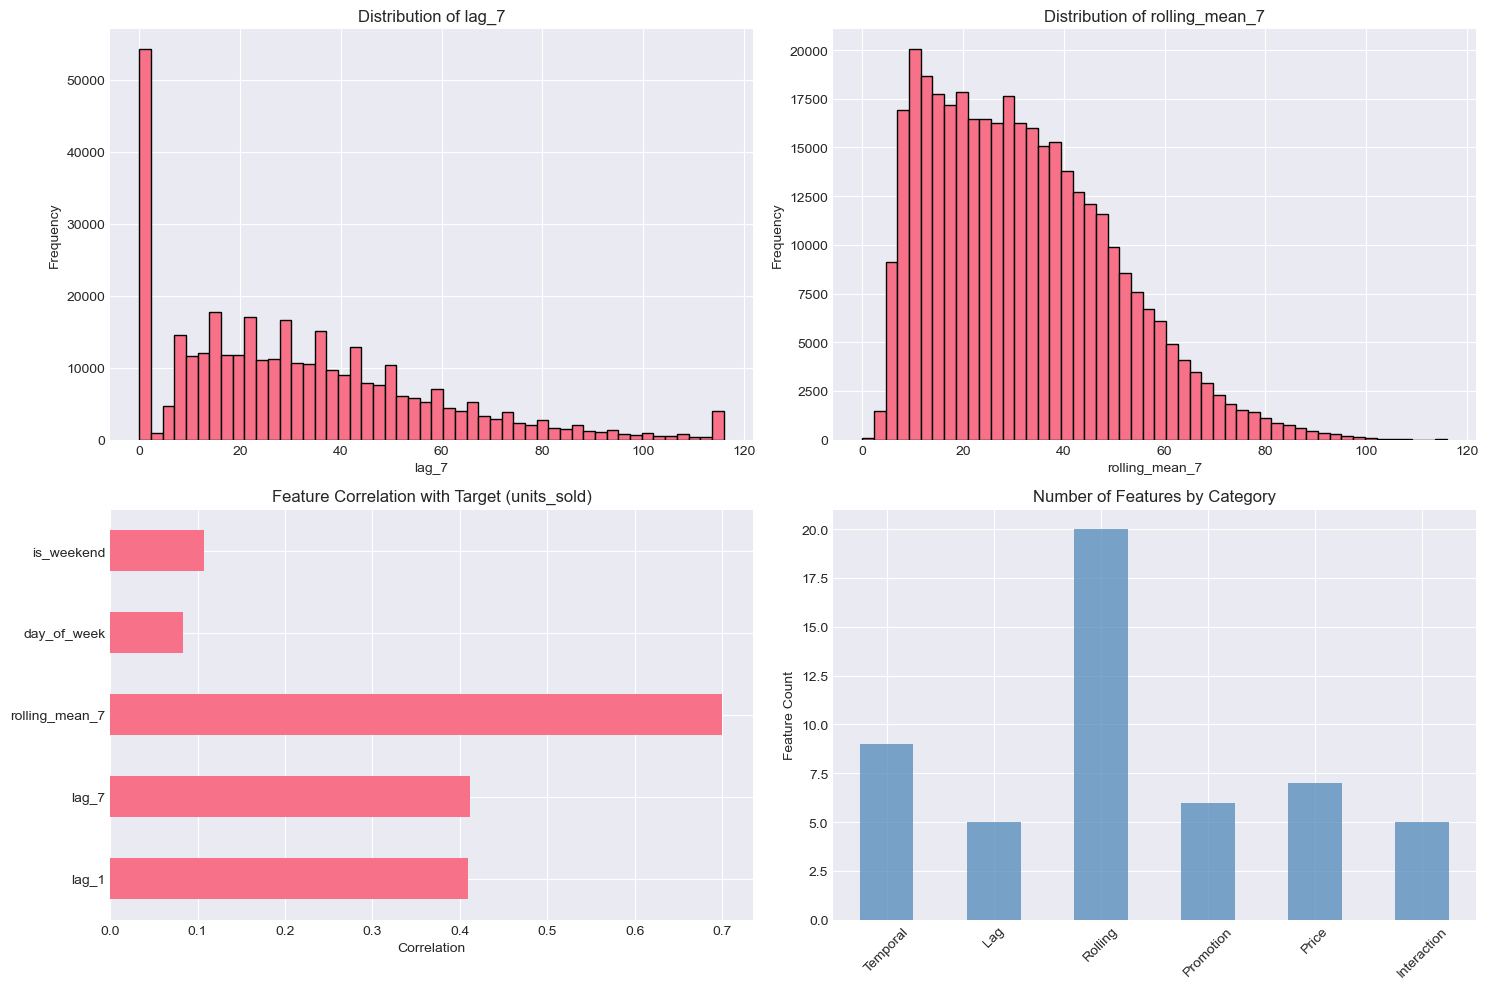

In [14]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Lag features
if 'lag_7' in df_features.columns:
    df_features['lag_7'].hist(bins=50, ax=axes[0, 0], edgecolor='black')
    axes[0, 0].set_title('Distribution of lag_7')
    axes[0, 0].set_xlabel('lag_7')
    axes[0, 0].set_ylabel('Frequency')

# Rolling mean
if 'rolling_mean_7' in df_features.columns:
    df_features['rolling_mean_7'].hist(bins=50, ax=axes[0, 1], edgecolor='black')
    axes[0, 1].set_title('Distribution of rolling_mean_7')
    axes[0, 1].set_xlabel('rolling_mean_7')
    axes[0, 1].set_ylabel('Frequency')

# Feature correlation with target
if 'units_sold' in df_features.columns:
    numeric_features = df_features.select_dtypes(include=[np.number]).columns
    # Select key features for correlation
    key_features = ['lag_1', 'lag_7', 'rolling_mean_7', 'day_of_week', 'is_weekend']
    available_features = [f for f in key_features if f in numeric_features]
    if available_features:
        corr_with_target = df_features[available_features + ['units_sold']].corr()['units_sold'].drop('units_sold')
        corr_with_target.plot(kind='barh', ax=axes[1, 0])
        axes[1, 0].set_title('Feature Correlation with Target (units_sold)')
        axes[1, 0].set_xlabel('Correlation')

# Feature count by category
category_counts = {cat: len(features) for cat, features in feature_categories.items() if features}
if category_counts:
    pd.Series(category_counts).plot(kind='bar', ax=axes[1, 1], color='steelblue', alpha=0.7)
    axes[1, 1].set_title('Number of Features by Category')
    axes[1, 1].set_ylabel('Feature Count')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/visualizations/feature_engineering.png', dpi=300, bbox_inches='tight')
plt.show()


## Part 4: Save Processed Data

Save the cleaned and feature-engineered dataset for use in modeling.


In [15]:
# Handle missing values in critical features before saving
# Drop rows with missing lag features (first few rows per SKU)
critical_features = ['lag_7', 'rolling_mean_7']
available_critical = [f for f in critical_features if f in df_features.columns]

if available_critical:
    print(f"Dropping rows with missing {available_critical}...")
    initial_rows = len(df_features)
    df_features = df_features.dropna(subset=available_critical)
    dropped_rows = initial_rows - len(df_features)
    print(f"  Dropped {dropped_rows} rows ({dropped_rows/initial_rows*100:.2f}%)")
    print(f"  Remaining rows: {len(df_features)}")

# Save processed data
output_path = Path('../data/processed/featured_sales_data.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)

df_features.to_csv(output_path, index=False)
print(f"\n✓ Saved processed data to: {output_path}")
print(f"  Shape: {df_features.shape}")
print(f"  Columns: {len(df_features.columns)}")


Dropping rows with missing ['lag_7', 'rolling_mean_7']...
  Dropped 3500 rows (0.96%)
  Remaining rows: 361500

✓ Saved processed data to: ..\data\processed\featured_sales_data.csv
  Shape: (361500, 65)
  Columns: 65


## Summary

Feature engineering complete! Key accomplishments:

1. ✅ **Data Cleaning**
   - Filled missing dates
   - Handled outliers
   - Validated data quality

2. ✅ **Feature Engineering**
   - Temporal features (day, month, seasonality)
   - Lag features (historical patterns)
   - Rolling statistics (trends and volatility)
   - Promotion features
   - Price features
   - Interaction features

3. ✅ **Data Ready for Modeling**
   - Clean, validated dataset
   - Rich feature set
   - Saved for use in Module 3+

**Next Steps:**
- Use this dataset in Module 3 (Baseline Models)
- Features are ready for machine learning models
- Consider feature selection in later modules
